PLOTS TODO:
- Bar plot comparing mAP@0.5:0.95 for all the methods of fine-tuning head (normal, augs_basic, augs_weather)
- A plot to see if LoRA is better than doing full-finetune.
- A plot to see how each model performs better depending on the size of the objects
- The normal plots of convergence of mAP and loss. I saw many strange things on these plots of wandb and i want to see a better analysis of these, apart from the normal ones. 
- For DETR, a dual axis plot showing the validation loss and the validation mAP.
- For the inference, just tables will be fine.

MORE
- A plot for the FRNN of mAP for each type of object (small, medium, large) to see the performance and do some insights.

In [8]:
from src.plot_metrics import *

# --- Load DETR Data ---
# (Replace the folder names with your exact generated folder names)
detr_inference = load_metrics("results/step0_detr_inference_jjvmmt17")
detr_head = load_metrics("results/step1_detr_head_baseline_7t7vd9cz")
detr_basic = load_metrics("results/step2_detr_augs_basic_elj1khza")
detr_weather = load_metrics("results/step2_detr_augs_weather_hbnktlpu")
detr_full = load_metrics("results/step3_detr_full_finetune_8lntoxl4")
detr_lora = load_metrics("results/step3_detr_full_finetune_lora_30_0ynqrb10")

# --- Load FRNN Data ---
frnn_inference = load_metrics("results/step0_frnn_inference_i8bhj3aj")
frnn_head = load_metrics("results/step1_frnn_head_baseline_tu11d9jw")
frnn_basic = load_metrics("results/step2_frnn_augs_basic_m6bmrapg")
frnn_weather = load_metrics("results/step2_frnn_augs_weather_uibqltdf")
frnn_full = load_metrics("results/step3_frnn_full_finetune_jt08hm1m")
frnn_lora = load_metrics("results/step3_frnn_partial_unfreeze_rh9utsc8")

/export/home/group05/alvaro/MCV-C5/Task1/src/plot_metrics.py:176: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x=names, y=best_maps, palette=PASTEL_COLORS[:len(names)],


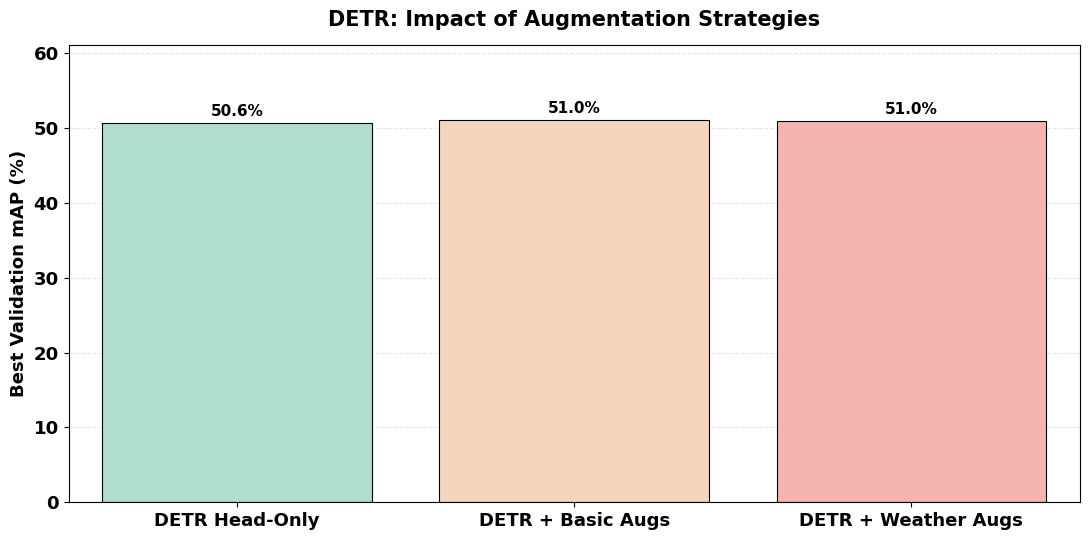

In [9]:
# Did the weather augmentations improve robustness over the baseline?
augs_dict = {
    "DETR Head-Only": detr_head,
    "DETR + Basic Augs": detr_basic,
    "DETR + Weather Augs": detr_weather
}
plot_augmentation_impact(augs_dict, title="DETR: Impact of Augmentation Strategies")

/export/home/group05/alvaro/MCV-C5/Task1/src/plot_metrics.py:176: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x=names, y=best_maps, palette=PASTEL_COLORS[:len(names)],


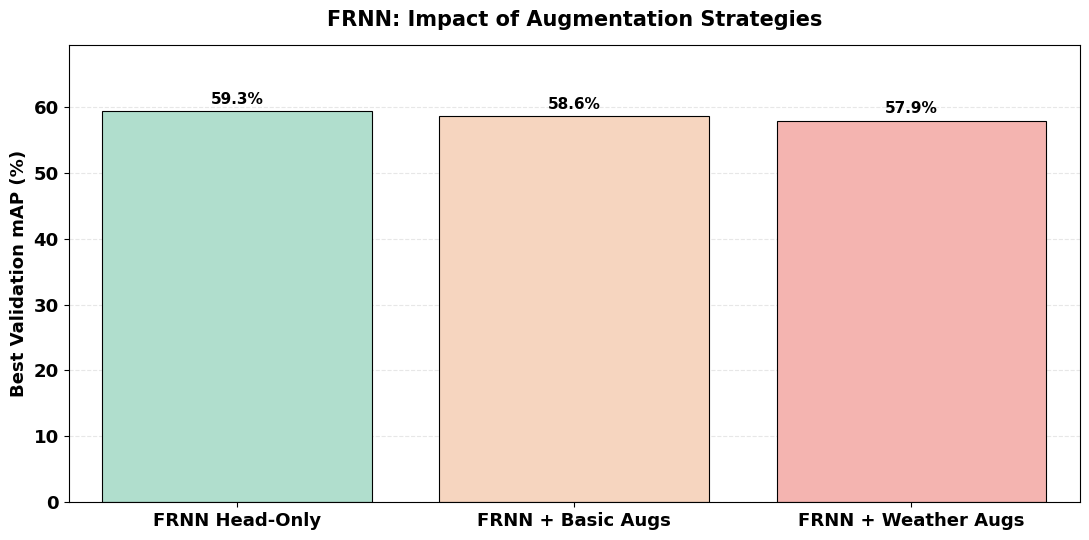

In [10]:
# Did the weather augmentations improve robustness over the baseline?
augs_dict = {
    "FRNN Head-Only": frnn_head,
    "FRNN + Basic Augs": frnn_basic,
    "FRNN + Weather Augs": frnn_weather
}
plot_augmentation_impact(augs_dict, title="FRNN: Impact of Augmentation Strategies")

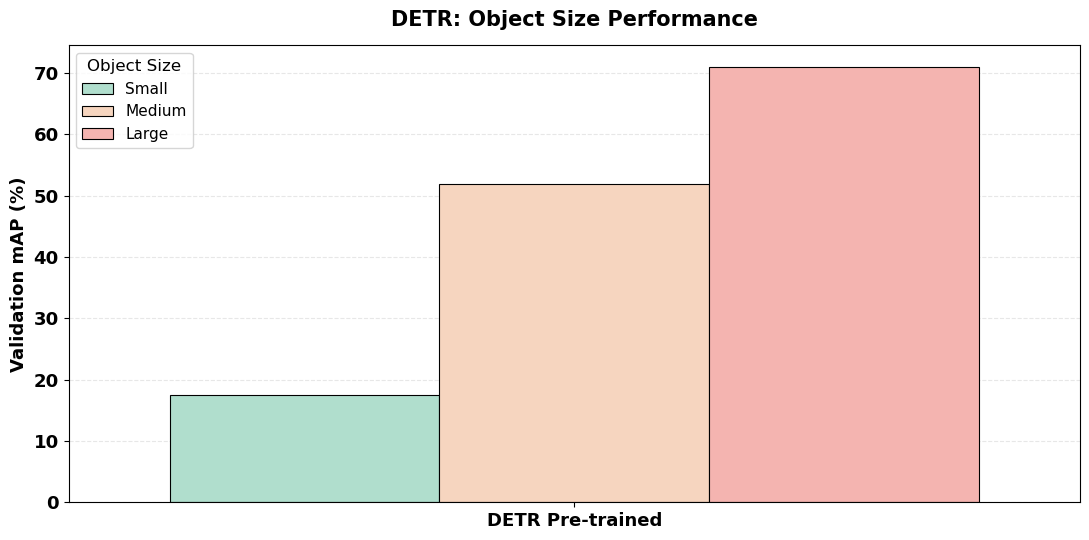

In [11]:
# How do different models handle distance (Small vs Large objects)?
size_dict = {
    "DETR Pre-trained": detr_inference,
}
plot_object_size_performance(size_dict, title="DETR: Object Size Performance")

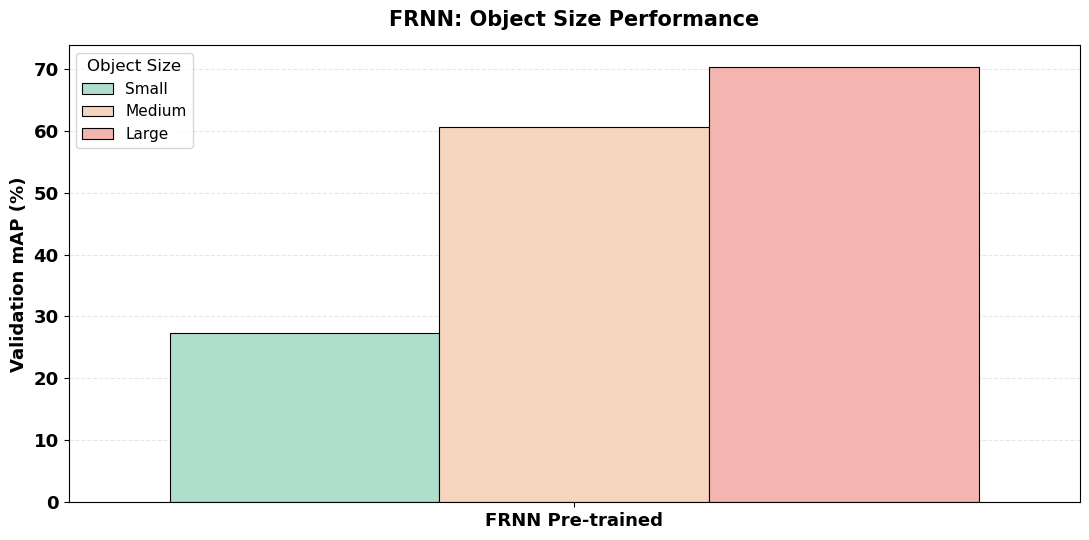

In [12]:
# How do different models handle distance (Small vs Large objects)?
size_dict = {
    "FRNN Pre-trained": frnn_inference # Compare your best runs here
}
plot_object_size_performance(size_dict, title="FRNN: Object Size Performance")

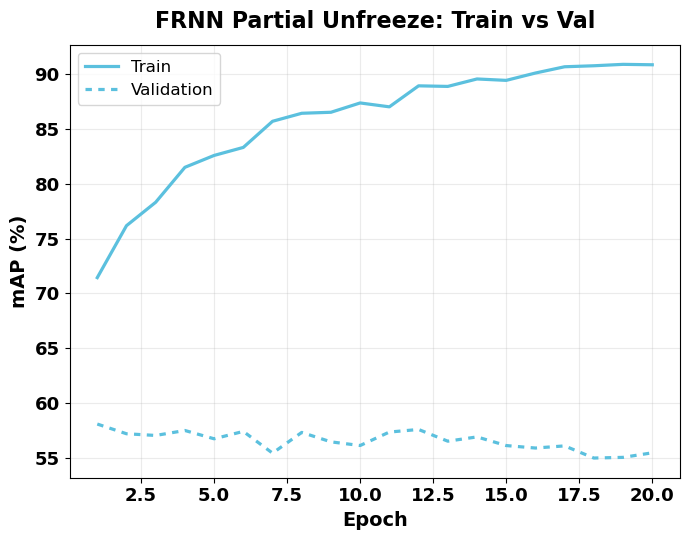

In [13]:
# Load your best model
frnn_best = load_metrics("results/step3_frnn_partial_unfreeze_14kui2dx")

plot_single_experiment_train_val(
    df=frnn_best, 
    metric_suffix="mAP_0.50_0.95_all", # Looks for train/... and val/...
    title="FRNN Partial Unfreeze: Train vs Val", 
    ylabel="mAP (%)",
    base_color="cyan" # Use cyan, tomato, or green
)

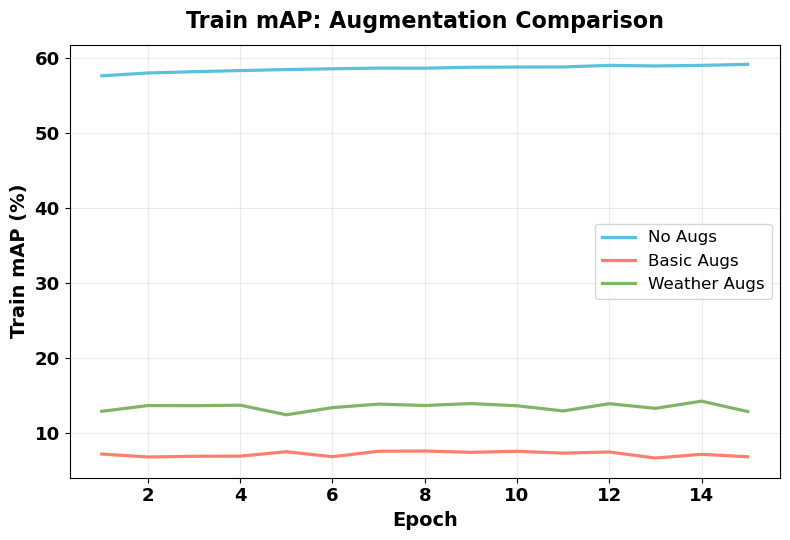

In [14]:
frnn_augs_dict = {
    "No Augs": frnn_head,
    "Basic Augs": frnn_basic,
    "Weather Augs": frnn_weather
}

# Plot only the Validation mAP for all 3 models
plot_wandb_style_comparison(
    experiments_dict=frnn_augs_dict, 
    metric_name="train/mAP_0.50_0.95_all", # The exact JSON key you want to overlay
    title="Train mAP: Augmentation Comparison", 
    ylabel="Train mAP (%)"
)

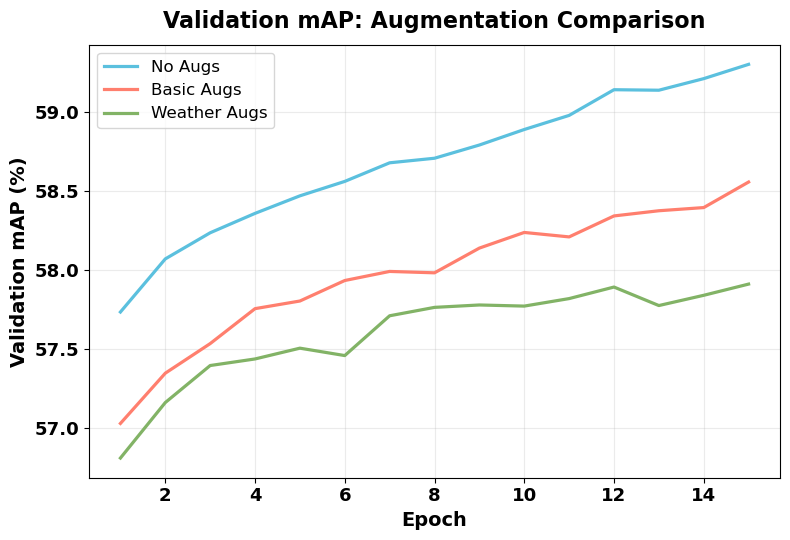

In [15]:
frnn_augs_dict = {
    "No Augs": frnn_head,
    "Basic Augs": frnn_basic,
    "Weather Augs": frnn_weather
}

# Plot only the Validation mAP for all 3 models
plot_wandb_style_comparison(
    experiments_dict=frnn_augs_dict, 
    metric_name="val/mAP_0.50_0.95_all", # The exact JSON key you want to overlay
    title="Validation mAP: Augmentation Comparison", 
    ylabel="Validation mAP (%)"
)

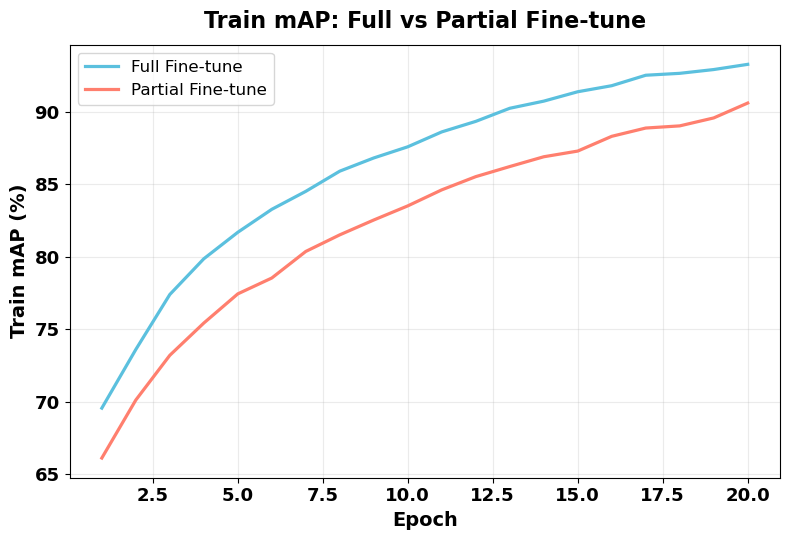

In [16]:
frnn_dict = {
    "Full Fine-tune": frnn_full,
    "Partial Fine-tune": frnn_lora,
}

# Plot only the Validation mAP for all 3 models
plot_wandb_style_comparison(
    experiments_dict=frnn_dict, 
    metric_name="train/mAP_0.50_0.95_all", # The exact JSON key you want to overlay
    title="Train mAP: Full vs Partial Fine-tune", 
    ylabel="Train mAP (%)"
)

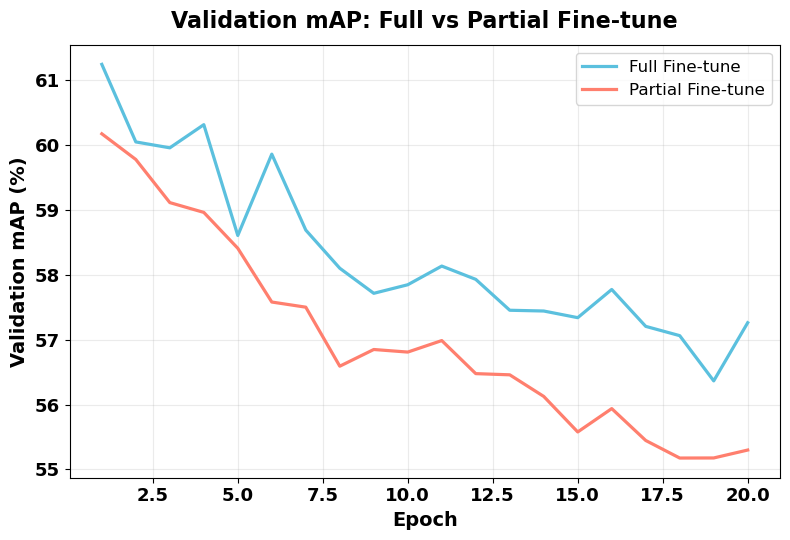

In [17]:
frnn_dict = {
    "Full Fine-tune": frnn_full,
    "Partial Fine-tune": frnn_lora,
}

# Plot only the Validation mAP for all 3 models
plot_wandb_style_comparison(
    experiments_dict=frnn_dict, 
    metric_name="val/mAP_0.50_0.95_all", # The exact JSON key you want to overlay
    title="Validation mAP: Full vs Partial Fine-tune", 
    ylabel="Validation mAP (%)"
)

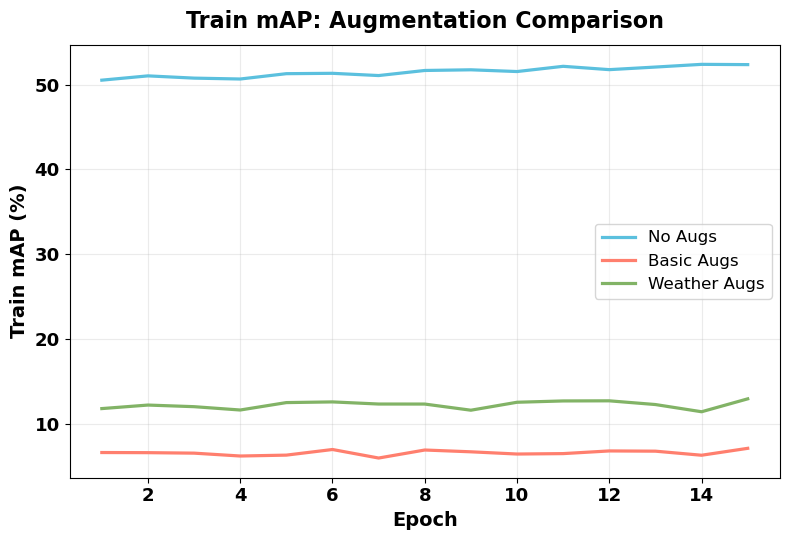

In [18]:
detr_augs_dict = {
    "No Augs": detr_head,
    "Basic Augs": detr_basic,
    "Weather Augs": detr_weather
}

# Plot only the Validation mAP for all 3 models
plot_wandb_style_comparison(
    experiments_dict=detr_augs_dict, 
    metric_name="train/mAP_0.50_0.95_all", # The exact JSON key you want to overlay
    title="Train mAP: Augmentation Comparison", 
    ylabel="Train mAP (%)"
)

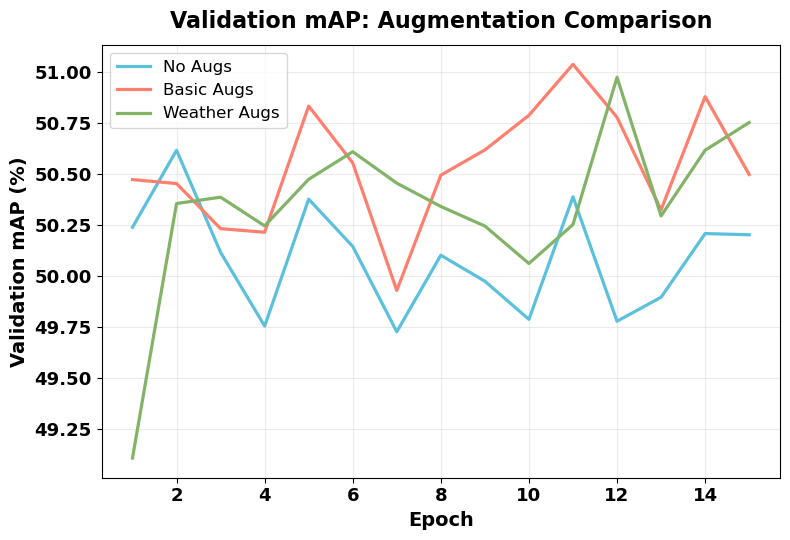

In [19]:
detr_augs_dict = {
    "No Augs": detr_head,
    "Basic Augs": detr_basic,
    "Weather Augs": detr_weather
}

# Plot only the Validation mAP for all 3 models
plot_wandb_style_comparison(
    experiments_dict=detr_augs_dict, 
    metric_name="val/mAP_0.50_0.95_all", # The exact JSON key you want to overlay
    title="Validation mAP: Augmentation Comparison", 
    ylabel="Validation mAP (%)"
)

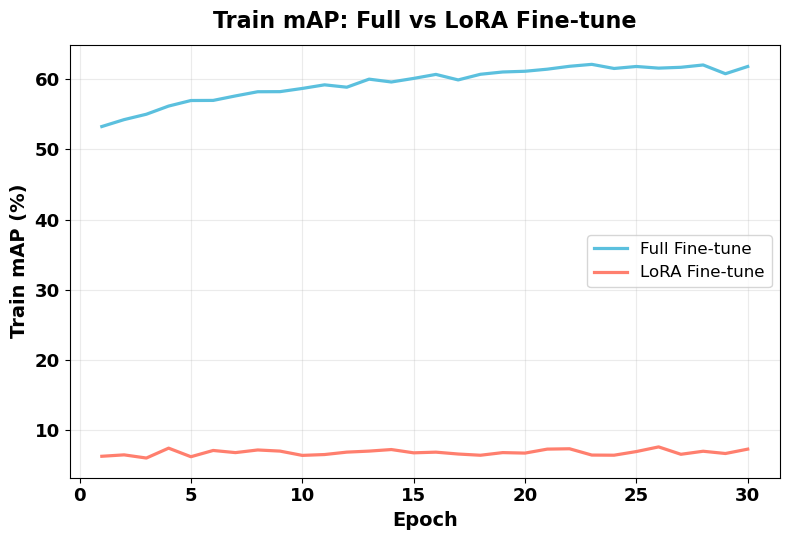

In [20]:
detr_dict = {
    "Full Fine-tune": detr_full,
    "LoRA Fine-tune": detr_lora
}

# Plot only the Validation mAP for all 3 models
plot_wandb_style_comparison(
    experiments_dict=detr_dict, 
    metric_name="train/mAP_0.50_0.95_all", # The exact JSON key you want to overlay
    title="Train mAP: Full vs LoRA Fine-tune", 
    ylabel="Train mAP (%)"
)

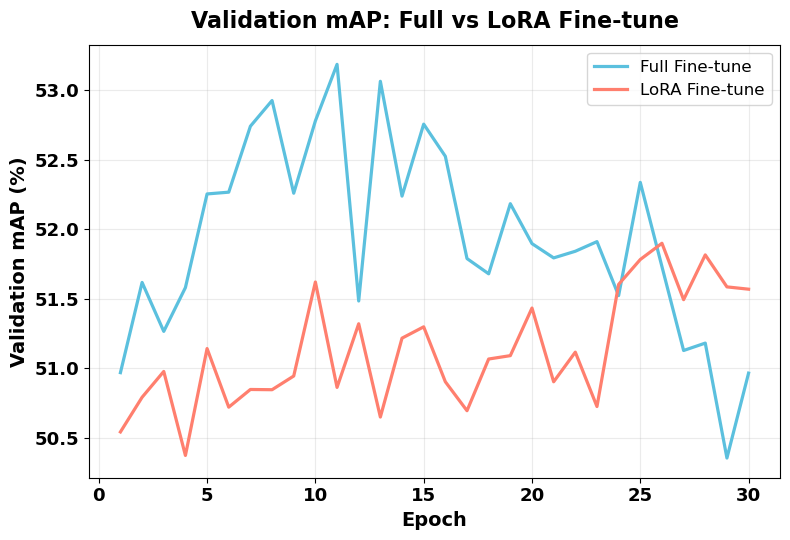

In [21]:
detr_dict = {
    "Full Fine-tune": detr_full,
    "LoRA Fine-tune": detr_lora,
}

# Plot only the Validation mAP for all 3 models
plot_wandb_style_comparison(
    experiments_dict=detr_dict, 
    metric_name="val/mAP_0.50_0.95_all", # The exact JSON key you want to overlay
    title="Validation mAP: Full vs LoRA Fine-tune", 
    ylabel="Validation mAP (%)"
)

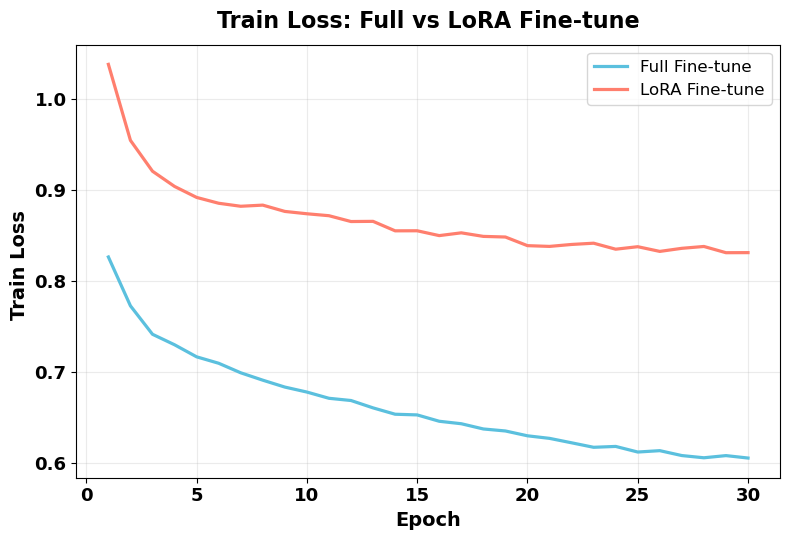

In [22]:
detr_dict = {
    "Full Fine-tune": detr_full,
    "LoRA Fine-tune": detr_lora
}

# Plot only the Validation mAP for all 3 models
plot_wandb_style_comparison(
    experiments_dict=detr_dict, 
    metric_name="train/total_loss", # The exact JSON key you want to overlay
    title="Train Loss: Full vs LoRA Fine-tune", 
    ylabel="Train Loss "
)

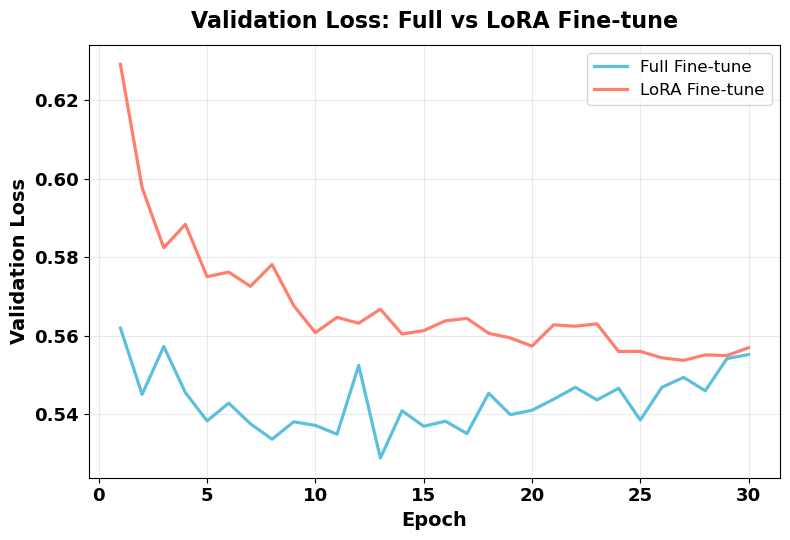

In [23]:
detr_dict = {
    "Full Fine-tune": detr_full,
    "LoRA Fine-tune": detr_lora,
}

# Plot only the Validation mAP for all 3 models
plot_wandb_style_comparison(
    experiments_dict=detr_dict, 
    metric_name="val/total_loss", # The exact JSON key you want to overlay
    title="Validation Loss: Full vs LoRA Fine-tune", 
    ylabel="Validation Loss"
)

In [ ]:
from src.plot_metrics import *

# PARA DEART

# detr_inference = load_metrics("results/step0_detr_inference_jjvmmt17")
detr_head = load_metrics("results/DETR_head_qpx0o4dj")
detr_basic = load_metrics("results/DETR_head_augbasic_bvwrpy76")
detr_lora = load_metrics("results/DETR_lora_355smhkl")


# --- Load FRNN Data ---
# frnn_inference = load_metrics("results/step0_frnn_inference_i8bhj3aj")
frnn_head = load_metrics("results/FRNN_head_jkn274i0")
frnn_basic = load_metrics("results/FRNN_head_augbasic_r2apdept")
frnn_partial = load_metrics("results/FRNN_partial_finetune_lqu7xt4b")


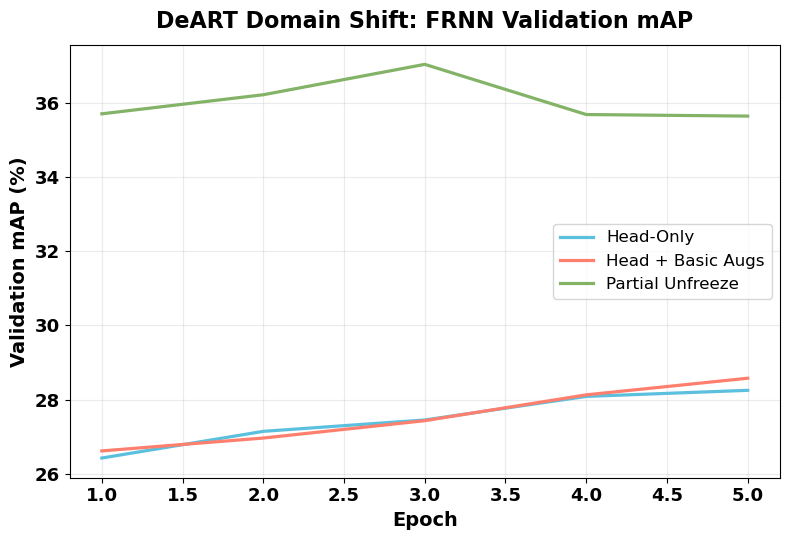

In [30]:

# Group the FRNN models
frnn_deart_dict = {
    "Head-Only": frnn_head,
    "Head + Basic Augs": frnn_basic,
    "Partial Unfreeze": frnn_partial
}

# Plot the Validation mAP trajectory for all 3 models
plot_wandb_style_comparison(
    experiments_dict=frnn_deart_dict, 
    metric_name="val/mAP_0.50_0.95_all", 
    title="DeART Domain Shift: FRNN Validation mAP", 
    ylabel="Validation mAP (%)"
)

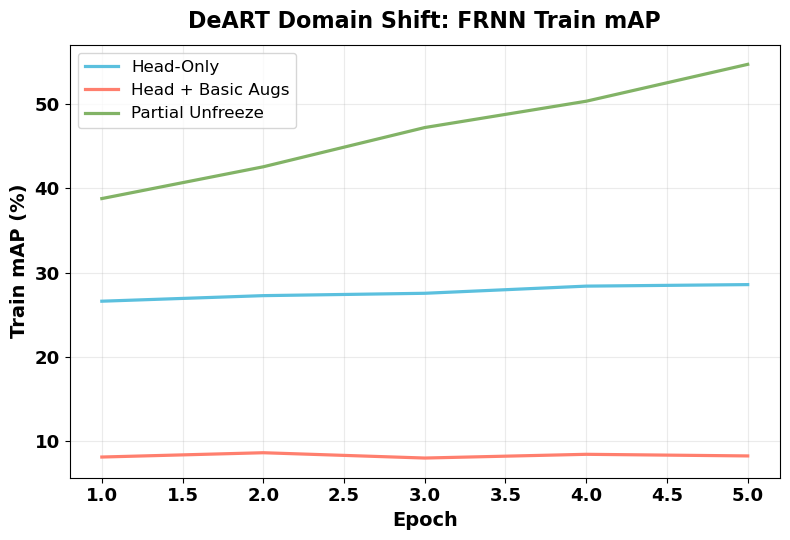

In [44]:

# Group the FRNN models
frnn_deart_dict = {
    "Head-Only": frnn_head,
    "Head + Basic Augs": frnn_basic,
    "Partial Unfreeze": frnn_partial
}

# Plot the Validation mAP trajectory for all 3 models
plot_wandb_style_comparison(
    experiments_dict=frnn_deart_dict, 
    metric_name="train/mAP_0.50_0.95_all", 
    title="DeART Domain Shift: FRNN Train mAP", 
    ylabel="Train mAP (%)"
)

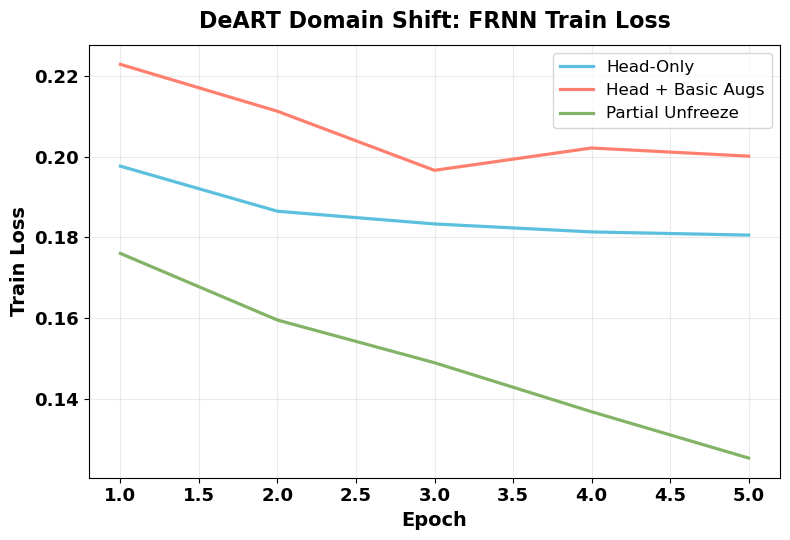

In [50]:
# Group the FRNN models
frnn_deart_dict = {
    "Head-Only": frnn_head,
    "Head + Basic Augs": frnn_basic,
    "Partial Unfreeze": frnn_partial
}

# Plot the Validation mAP trajectory for all 3 models
plot_wandb_style_comparison(
    experiments_dict=frnn_deart_dict, 
    metric_name="train/total_loss", 
    title="DeART Domain Shift: FRNN Train Loss", 
    ylabel="Train Loss"
)

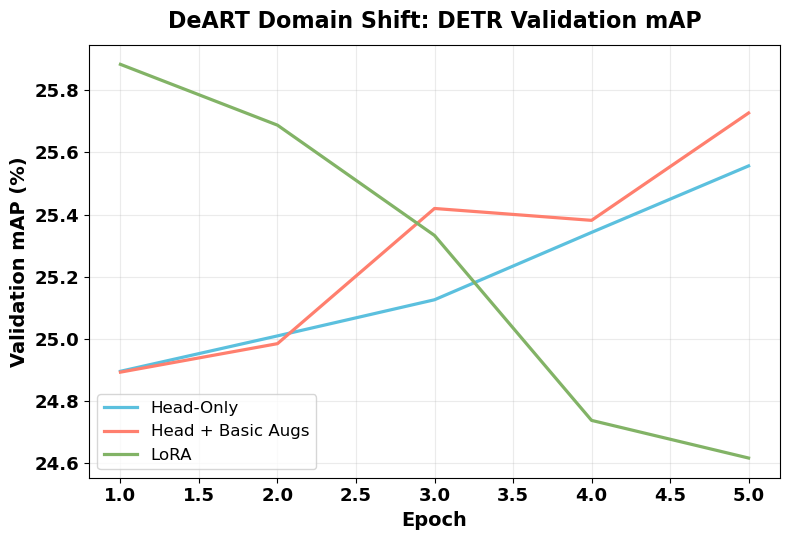

In [46]:
# Group the DETR models
detr_deart_dict = {
    "Head-Only": detr_head,
    "Head + Basic Augs": detr_basic,
    "LoRA": detr_lora
}

# Plot side-by-side Train vs Val mAP
plot_wandb_style_comparison(
    experiments_dict=detr_deart_dict,
    metric_name="val/mAP_0.50_0.95_all", 
    title="DeART Domain Shift: DETR Validation mAP",
    ylabel="Validation mAP (%)"
)

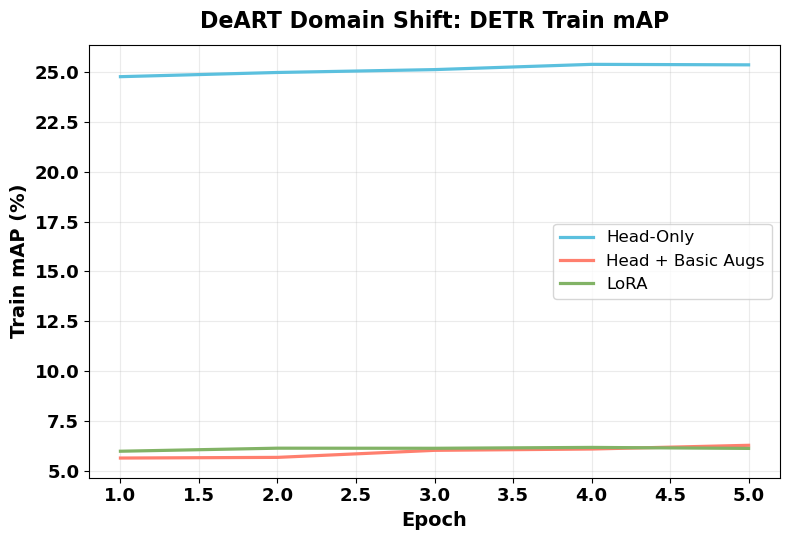

In [47]:
# Group the DETR models
detr_deart_dict = {
    "Head-Only": detr_head,
    "Head + Basic Augs": detr_basic,
    "LoRA": detr_lora
}

# Plot side-by-side Train vs Val mAP
plot_wandb_style_comparison(
    experiments_dict=detr_deart_dict,
    metric_name="train/mAP_0.50_0.95_all", 
    title="DeART Domain Shift: DETR Train mAP",
    ylabel="Train mAP (%)"
)

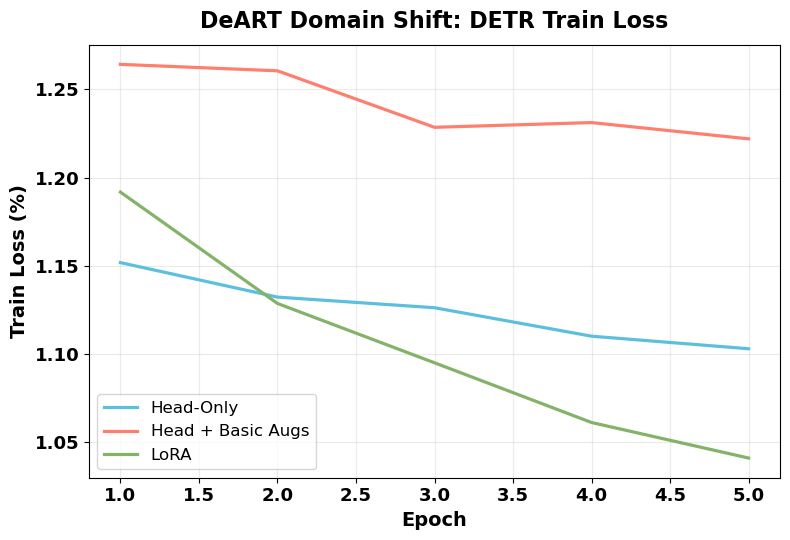

In [ ]:
# Group the DETR models
detr_deart_dict = {
    "Head-Only": detr_head,
    "Head + Basic Augs": detr_basic,
    "LoRA": detr_lora
}

# Plot the Validation mAP trajectory for all 3 models
plot_wandb_style_comparison(
    experiments_dict=detr_deart_dict, 
    metric_name="train/total_loss", 
    title="DeART Domain Shift: DETR Train Loss", 
    ylabel="Train Loss"
)

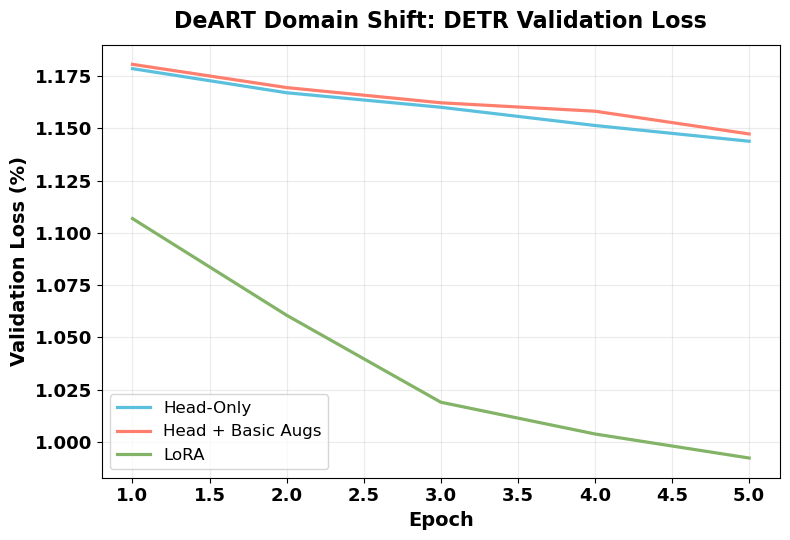

In [ ]:
# Group the DETR models
detr_deart_dict = {
    "Head-Only": detr_head,
    "Head + Basic Augs": detr_basic,
    "LoRA": detr_lora
}

# Plot the Validation mAP trajectory for all 3 models
plot_wandb_style_comparison(
    experiments_dict=detr_deart_dict, 
    metric_name="val/total_loss", 
    title="DeART Domain Shift: DETR Validation Loss", 
    ylabel="Validation Loss"
)

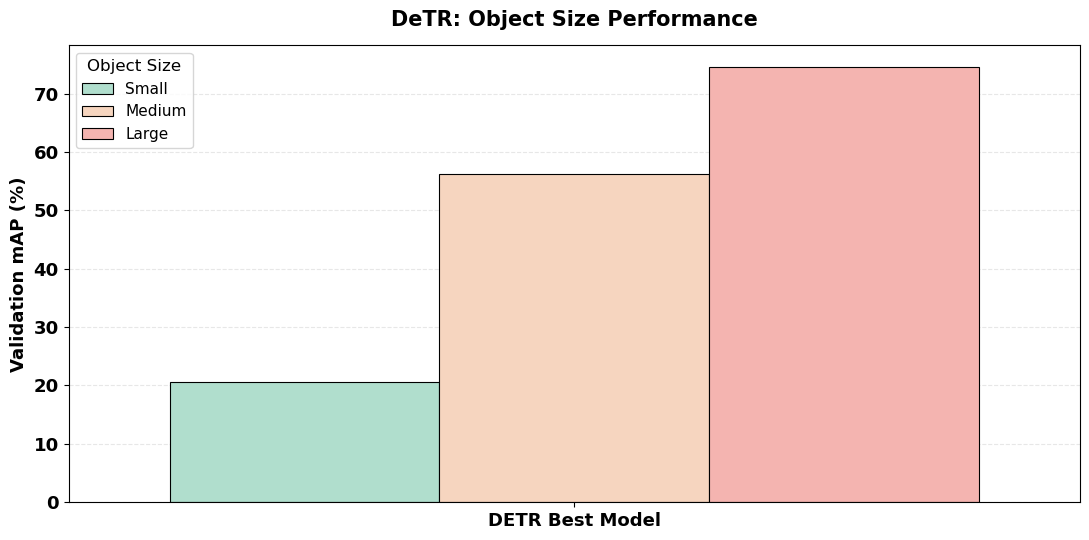

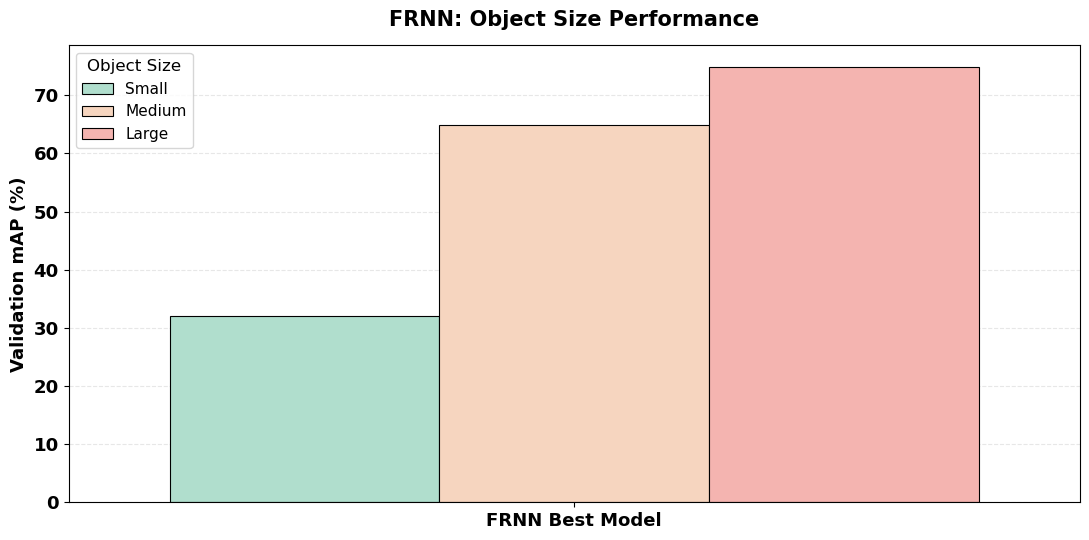

In [7]:
detr = load_metrics("results/lora_sweep_w2vmrv4p_w2vmrv4p")

# --- Load FRNN Data ---
frnn = load_metrics("results/lora_sweep_jh41psgf_jh41psgf")

size_dict = {
    "DETR Best Model": detr # Compare your best runs here
}
plot_object_size_performance(size_dict, title="DeTR: Object Size Performance")

# How do different models handle distance (Small vs Large objects)?
size_dict = {
    "FRNN Best Model": frnn # Compare your best runs here
}
plot_object_size_performance(size_dict, title="FRNN: Object Size Performance")

In [25]:
def plot_compare_models_by_size(experiments_dict, title="Model Comparison by Object Size"):
    """
    Grouped bar chart comparing multiple models across Small, Medium, and Large objects.
    X-axis: Object Size
    Hue: Model Name
    """
    data = []
    for exp_name, df in experiments_dict.items():
        # Get the row with the best overall mAP
        best_idx = df['val/mAP_0.50_0.95_all'].idxmax()
        best_row = df.loc[best_idx]
        
        data.append({'Model': exp_name, 'Size': 'Small', 'mAP': best_row['val/mAP_0.50_0.95_small'] * 100})
        data.append({'Model': exp_name, 'Size': 'Medium', 'mAP': best_row['val/mAP_0.50_0.95_medium'] * 100})
        data.append({'Model': exp_name, 'Size': 'Large', 'mAP': best_row['val/mAP_0.50_0.95_large'] * 100})
        
    plot_df = pd.DataFrame(data)
    
    plt.figure(figsize=(11, 5.5))
    
    # Swap X and Hue: Now Size is the group, Model is the color
    sns.barplot(data=plot_df, x='Size', y='mAP', hue='Model', 
                palette=PASTEL_COLORS[:len(experiments_dict)], 
                edgecolor="black", linewidth=0.8)
                
    # Styling (Teammate's aesthetic)
    plt.title(title, fontsize=15, fontweight="bold", pad=14)
    plt.ylabel("Validation mAP (%)", fontsize=13, fontweight="bold")
    plt.xlabel("Object Size", fontsize=13, fontweight="bold")
    plt.xticks(fontsize=13, fontweight="bold")
    plt.yticks(fontsize=13, fontweight="bold")
    
    plt.grid(axis="y", linestyle="--", alpha=0.3)
    plt.gca().set_axisbelow(True)
    plt.legend(title="Model", fontsize=11, title_fontsize=12, frameon=True)
    plt.tight_layout()
    plt.show()

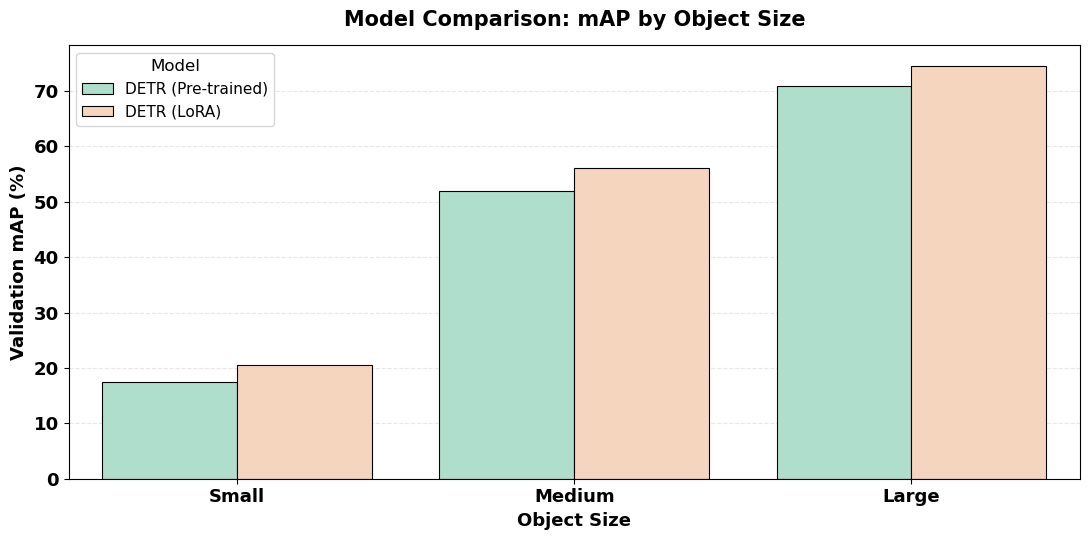

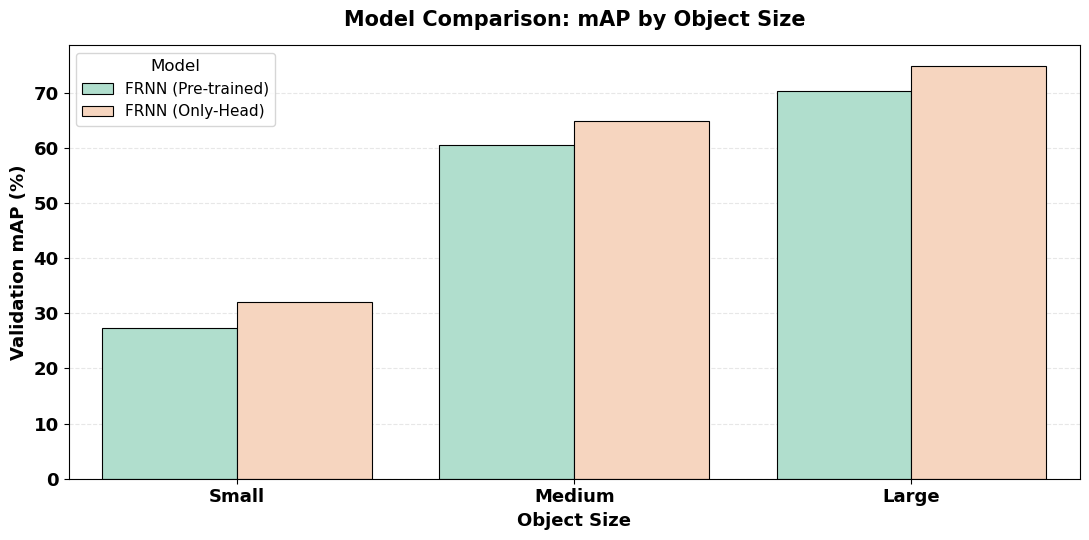

In [27]:
# 1. Load your best results
# Replace these paths with your actual best run folders
detr_best = load_metrics("results/lora_sweep_w2vmrv4p_w2vmrv4p")
frnn_best = load_metrics("results/lora_sweep_jh41psgf_jh41psgf")

# --- Load DETR Data ---
# (Replace the folder names with your exact generated folder names)
detr_inference = load_metrics("results/step0_detr_inference_jjvmmt17")
frnn_inference = load_metrics("results/step0_frnn_inference_i8bhj3aj")

# 2. Package into the dictionary
comparison_dict = {
    "DETR (Pre-trained)": detr_inference,
    "DETR (LoRA)": detr_best
}

# 3. Generate the plot
plot_compare_models_by_size(
    comparison_dict, 
    title="Model Comparison: mAP by Object Size"
)

comparison_dict = {
    "FRNN (Pre-trained)": frnn_inference,
    "FRNN (Only-Head)": frnn_best
}

# 3. Generate the plot
plot_compare_models_by_size(
    comparison_dict, 
    title="Model Comparison: mAP by Object Size"
)

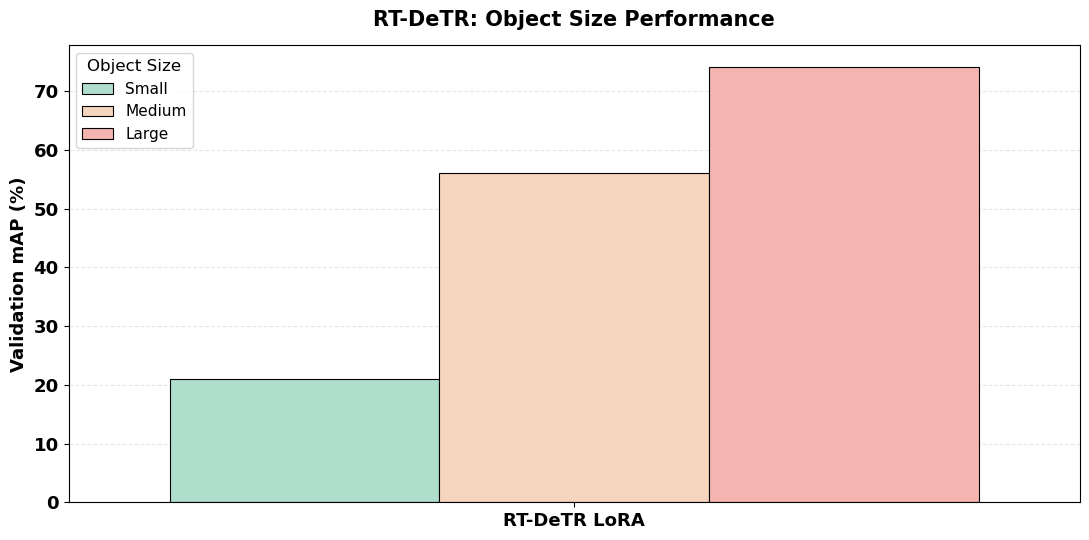

In [34]:
rtdetr_inference = load_metrics("results/RT_DeTR_LoRA_i1g8slhu")

# How do different models handle distance (Small vs Large objects)?
size_dict = {
    "RT-DeTR LoRA": rtdetr_inference,
}
plot_object_size_performance(size_dict, title="RT-DeTR: Object Size Performance")

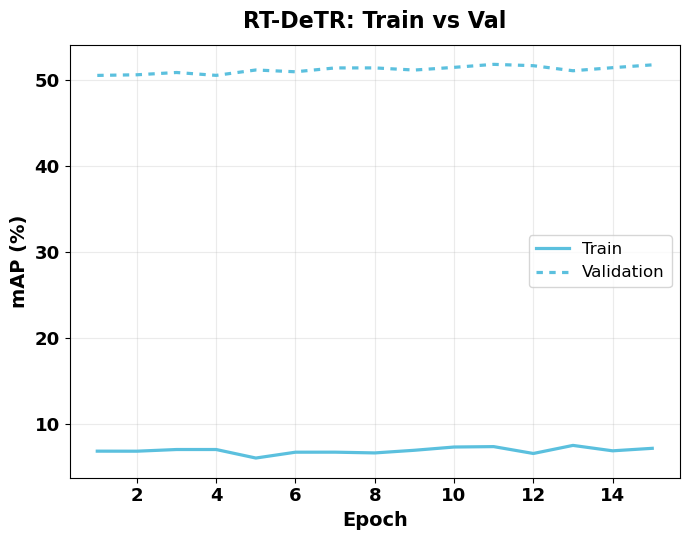

In [32]:
# Load your best model

plot_single_experiment_train_val(
    df=rtdetr_inference, 
    metric_suffix="mAP_0.50_0.95_all", # Looks for train/... and val/...
    title="RT-DeTR: Train vs Val", 
    ylabel="mAP (%)",
    base_color="cyan" # Use cyan, tomato, or green
)